In [1]:
#################################################################################
# Main script to run UP-MAVT analysis
#
# Simone Pagliuca, 2025-2026
#
# Description:
# TBC....
#################################################################################

#################################################################################
# Import third party libraries
import numpy as np
# import matplotlib
# matplotlib.use('TkAgg')  # Set backend before importing pyplot
import matplotlib.pyplot as plt
import seaborn as sns
import os
import csv
#################################################################################

#################################################################################
# Import internal modules
from pile_bwt import bwt, constraints_func
from up_mavt import startup, mc_simulation
from aggregation_methods import weighted_sum
from weight_sampling import obtain_weight_space_description
#################################################################################

#################################################################################
# USER INPUTS
# Weight elicitation files (one per elicitation / run)
file_path_weight_elicitations = ["wbt_results_1.csv"]
file_path_weight_elicitations = ["wbt_results_alt.csv"]


# Value function files (one per elicitation / run)
file_path_value_functions = ["value_functions_1.csv"]

# Criteria definitions file
file_path_criteria = "criteria.csv"

# Montecarlo Parameters
n_runs = 10000
PLOTS = True  # Toggle plots
UPDATE_EVERY = 10  # Update plots every N runs
#################################################################################


#################################################################################
# Startup: Load all data
dict_data_list, crit_index, vf_list, alternatives = startup(file_path_criteria, file_path_weight_elicitations, file_path_value_functions)
dict_data = dict_data_list[0]  # Use the first elicitation for testing
n_alternatives = len(alternatives)
print(f"Loaded {len(dict_data_list)} elicitation(s) with {n_alternatives} alternatives.")
#################################################################################

Number of criteria identified: 15
Loading criteria definitions and attaching value functions...
Starting loop over weight elicitation files...
Processing file 1/1: wbt_results_alt.csv
Loaded 1 elicitation(s) with 6 alternatives.


In [2]:

import numpy as np
import scipy.optimize as opt
from functools import partial

def constraints_func(x, dict_data, z_star=None, eps=0.001):
    cons = []
    group_indices = {}
    current_index = 0
    # Map group and criterion names to their global indices in x
    for group_name, group_data in dict_data.items():
        criteria_in_group = list(group_data['criteria'].keys())
        group_indices[group_name] = {
            'start': current_index,
            'end': current_index + len(criteria_in_group),
            'criteria': criteria_in_group
        }
        current_index += len(criteria_in_group)

    # INTRA-GROUP CONSTRAINTS
    for group_name, group_data in dict_data.items():
        criteria_in_group = group_indices[group_name]['criteria']
        w_start = group_indices[group_name]['start']
        w_end = group_indices[group_name]['end']
        w = x[w_start:w_end]  # Weights for this group
        z = x[-1]             # z is the last element
        for crit, comparisons in group_data['criteria'].items():
            i = criteria_in_group.index(crit)
            # INTRA-GROUP BEST COMPARISONS
            for other_crit, value in comparisons['best_comparisons'].items():
                j = criteria_in_group.index(other_crit)
                v_f = comparisons['value_function']
                v_f_val = max(v_f(value), eps)
                cons.append(z - abs(w[i] / (w[j] + eps) - 1.0 / v_f_val))
            # INTRA-GROUP WORST COMPARISONS
            for other_crit, value in comparisons['worst_comparisons'].items():
                j = criteria_in_group.index(other_crit)
                v_f_other = group_data['criteria'][other_crit]['value_function']
                v_f_other_val = max(v_f_other(value), eps)
                cons.append(z - abs(1.0 / v_f_other_val - (w[j] + eps) / (w[i] + eps)))

    # INTER-GROUP CONSTRAINTS
    intraB = {}
    intraW = {}
    for group_data in dict_data.values():
        intraB.update(group_data['intraB'])
        intraW.update(group_data['intraW'])

    def add_comparison_constraint(comparison, comparison_type, cons, x, group_indices, dict_data, eps=0.001):
        ref_crit = comparison['reference']
        other_crit = comparison['other']
        def resolve_group_and_global_index(crit):
            for group_name, group_data in dict_data.items():
                if crit in group_data['criteria']:
                    local_index = group_indices[group_name]['criteria'].index(crit)
                    return group_name, group_indices[group_name]['start'] + local_index

        ref_group, ref_global_index = resolve_group_and_global_index(ref_crit)
        other_group, other_global_index = resolve_group_and_global_index(other_crit)
        v_f = dict_data[ref_group]['criteria'][ref_crit]['value_function']
        v_f_other = dict_data[other_group]['criteria'][other_crit]['value_function']
        v_f_val = max(v_f(comparison['value']), eps)
        v_f_other_val = max(v_f_other(comparison['value']), eps)
        if comparison_type == "best":
            cons.append(x[-1] - abs((x[ref_global_index] + eps) / (x[other_global_index] + eps) - (1.0 / v_f_val)))
        else:  # worst
            cons.append(x[-1] - abs(1.0 / v_f_other_val - (x[other_global_index] + eps) / (x[ref_global_index] + eps)))

    for comparison in intraB.values():
        add_comparison_constraint(comparison, comparison["type"], cons, x, group_indices, dict_data, eps)
    for comparison in intraW.values():
        add_comparison_constraint(comparison, comparison["type"], cons, x, group_indices, dict_data, eps)

    if z_star is not None:
        cons.append(z_star - x[-1])

    return cons


In [16]:
def objective(x, var=-1):
    return x[var]  # z is the last variable
def max_constraint_violation(x, dict_data, z_star=None):
    cons = constraints_func(x, dict_data, z_star)
    return max(0, -min(cons)) if cons else 0
def global_optimization(dict_data, var=-1, z_star=None):
    num_criteria = sum(len(group_data['criteria']) for group_data in dict_data.values())
    # Use a finite upper bound for z (last variable) because SciPy requires finite bounds
    z_upper = 1000.0
    bounds = [(0.001, 1) for _ in range(num_criteria)] + [(0.0, z_upper)]
    def objective_for_de(x):
        # Penalize constraint violations and deviation from sum-to-one for weights
        penalty = 0.0
        # Large penalty multiplier to strongly discourage infeasible solutions
        PEN = 1e6
        penalty += PEN * max_constraint_violation(x, dict_data, z_star)
        penalty += PEN * abs(np.sum(x[:num_criteria]) - 1.0)
        return x[var] + penalty
    # Use penalty-based objective because some SciPy versions don't accept
    # constraint dicts for `differential_evolution`.
    result_de = opt.differential_evolution(
        objective_for_de,
        bounds,
        maxiter=1000,
        popsize=20,
        tol=1e-3,
        polish=True,
        seed=42
    )
    return result_de

def find_all_solutions(dict_data, z_star=None, num_restarts=100, eps=0.001):
    num_criteria = sum(len(group_data['criteria']) for group_data in dict_data.values())
    # Finite bound for z to satisfy optimizer requirements
    z_upper = 1000.0
    bounds = [(0.001, 1) for _ in range(num_criteria)] + [(0.0, z_upper)]
    # Step 1: Find global optimum
    global_result = global_optimization(dict_data, z_star=z_star)
    max_violation_opt = max_constraint_violation(global_result.x, dict_data, z_star)
    solutions = [global_result.x]
    # Step 2: Multi-start local optimization to find all solutions within tolerance
    rng = np.random.RandomState(42)
    for _ in range(num_restarts):
        x0_random = rng.uniform(0.001, 1, size=num_criteria + 1)
        x0_random[-1] = 0.1  # Initial guess for z
        res = opt.minimize(
            objective,
            x0_random,
            method='SLSQP',
            constraints=[
                {'type': 'ineq', 'fun': constraints_func, 'args': (dict_data, z_star)},
                {'type': 'eq', 'fun': lambda x: np.sum(x[:num_criteria]) - 1}
            ],
            bounds=bounds,
            options={'maxiter': 1000}
        )
        if max_constraint_violation(res.x, dict_data, z_star) <= max_violation_opt + eps:
            solutions.append(res.x)
    return {
        'global_optimum': global_result,
        'all_solutions': solutions,
        'max_violation_opt': max_violation_opt
    }

In [ ]:
# from pyDOE3 import lhs

# def find_all_solutions(dict_data, z_star=None, num_restarts=100, eps=0.001, seed=47):
#     num_criteria = sum(len(group_data['criteria']) for group_data in dict_data.values())
#     z_upper = 1000.0
#     bounds = [(0.001, 1) for _ in range(num_criteria)] + [(0.0, z_upper)]

#     # Step 1: Find global optimum
#     global_result = global_optimization(dict_data, z_star=z_star)
#     max_violation_opt = max_constraint_violation(global_result.x, dict_data, z_star)
#     solutions = [global_result.x]

#     # Step 2: Multi-start local optimization to find all solutions within tolerance
#     rng = np.random.RandomState(seed)
#     for ii in range(num_restarts):
#         print(f"Restart {ii+1}/{num_restarts}")
#         # Use Latin Hypercube Sampling for better space coverage
#         x0_random = lhs(num_criteria + 1, samples=1, criterion='center')[0]
#         x0_random = x0_random * 0.999 + 0.001  # Scale to [0.001, 1]
#         x0_random[-1] = 0.1  # Initial guess for z
#         res = opt.minimize(
#             objective,
#             x0_random,
#             method='trust-constr',  # Use trust-constr for better constraint handling
#             constraints=[
#                 {'type': 'ineq', 'fun': constraints_func, 'args': (dict_data, z_star)},
#                 {'type': 'eq', 'fun': lambda x: np.sum(x[:num_criteria]) - 1}
#             ],
#             bounds=bounds,
#             options={'maxiter': 1000}
#         )
#         if max_constraint_violation(res.x, dict_data, z_star) <= max_violation_opt + eps:
#             solutions.append(res.x)

#     # Deduplicate solutions at 0.001 resolution
#     rounded = np.round(solutions, 3)
#     _, uniq_idx = np.unique(rounded, axis=0, return_index=True)
#     unique_solutions = np.array(solutions)[uniq_idx]

#     return {
#         'global_optimum': global_result,
#         'all_solutions': unique_solutions,
#         'max_violation_opt': max_violation_opt
#     }

# # def find_all_solutions(dict_data, z_star=None, num_restarts=100, eps=0.001):
# #     num_criteria = sum(len(group_data['criteria']) for group_data in dict_data.values())
# #     # Finite bound for z to satisfy optimizer requirements
# #     z_upper = 1000.0
# #     bounds = [(0.001, 1) for _ in range(num_criteria)] + [(0.0, z_upper)]
# #     # Step 1: Find global optimum
# #     global_result = global_optimization(dict_data, z_star=z_star)
# #     max_violation_opt = max_constraint_violation(global_result.x, dict_data, z_star)
# #     solutions = [global_result.x]
# #     # Step 2: Multi-start local optimization to find all solutions within tolerance
# #     rng = np.random.RandomState(47)
# #     for _ in range(num_restarts):
# #         x0_random = rng.uniform(0.001, 1, size=num_criteria + 1)
# #         x0_random[-1] = 0.1  # Initial guess for z
# #         res = opt.minimize(
# #             objective,
# #             x0_random,
# #             method='SLSQP',
# #             constraints=[
# #                 {'type': 'ineq', 'fun': constraints_func, 'args': (dict_data, z_star)},
# #                 {'type': 'eq', 'fun': lambda x: np.sum(x[:num_criteria]) - 1}
# #             ],
# #             bounds=bounds,
# #             options={'maxiter': 1000}
# #         )
# #         if max_constraint_violation(res.x, dict_data, z_star) <= max_violation_opt + eps:
# #             solutions.append(res.x)
# #     return {
# #         'global_optimum': global_result,
# #         'all_solutions': solutions,
# #         'max_violation_opt': max_violation_opt
# #     }

In [17]:
# Example usage:
results = find_all_solutions(dict_data, z_star=None)
print("Global optimum:", results['global_optimum'])
print("All solutions within tolerance:", results['all_solutions'])
print("Maximum violation at optimum:", results['max_violation_opt'])


Global optimum:              message: Maximum number of iterations has been exceeded.
             success: False
                 fun: 33.28432783907465
                   x: [ 3.963e-02  1.686e-02 ...  4.910e-02  3.328e+01]
                 nit: 1000
                nfev: 320881
          population: [[ 3.963e-02  1.686e-02 ...  4.910e-02  3.328e+01]
                       [ 1.827e-02  2.352e-01 ...  3.676e-03  3.839e+02]
                       ...
                       [ 4.026e-02  1.190e-01 ...  2.195e-02  1.593e+02]
                       [ 1.473e-02  2.301e-01 ...  2.590e-02  6.054e+01]]
 population_energies: [ 3.328e+01  4.044e+02 ...  3.938e+02  1.369e+02]
                 jac: [ 4.049e+05  4.049e+05 ...  4.049e+05  1.000e+00]
All solutions within tolerance: [array([3.96273786e-02, 1.68633684e-02, 4.30072658e-02, 1.24019180e-01,
       1.86340335e-01, 1.32698572e-02, 1.18139352e-02, 5.98755972e-02,
       1.47088022e-01, 6.94850313e-02, 1.48593742e-01, 2.09874880e-02,
       5

In [18]:
print(len(results['all_solutions']))  # Number of solutions found

101


In [19]:
# Improved plots to visualize distribution density of found solutions
import pandas as pd
# Build weights array (n_solutions x n_criteria), drop last element (z)
raw_weights = np.array([sol[:-1] for sol in results['all_solutions'][1:]])
# Round to 3 decimals (0.001) and deduplicate
round_dec = 3
rounded = np.round(raw_weights, round_dec)
# Find unique rounded rows preserving first occurrence order
_, uniq_idx = np.unique(rounded, axis=0, return_index=True)
uniq_idx = np.sort(uniq_idx)
unique_weights = rounded[uniq_idx]
# Retrieve corresponding z values from original solutions (keep original z without rounding)
orig_sols = results['all_solutions']#[1:]
unique_z = [orig_sols[i][-1] for i in uniq_idx]
n_solutions, n_criteria = unique_weights.shape
crit_names = [f'Criterion {i+1}' for i in range(n_criteria)]
df = pd.DataFrame(unique_weights, columns=crit_names)
print(f'Total solutions found: {len(results["all_solutions"]) - 1}; Unique (rounded to 0.001): {n_solutions}')


Total solutions found: 100; Unique (rounded to 0.001): 2


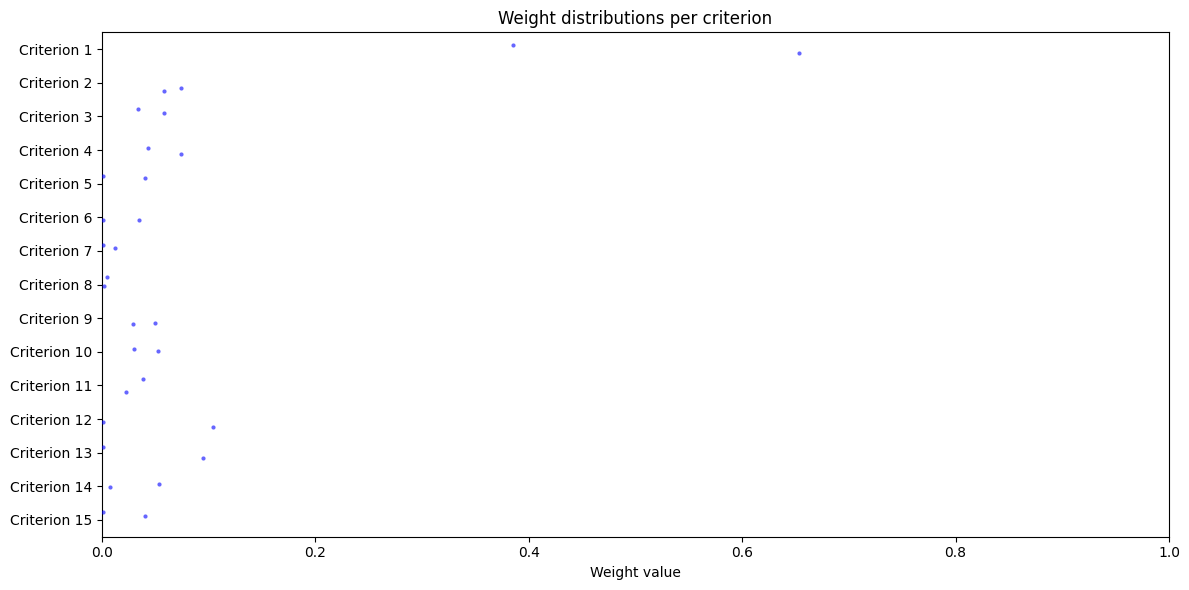

In [20]:

# 1) Violin plot with jittered points (shows distribution per criterion)
plt.figure(figsize=(12, 6))
# sns.violinplot(data=df, orient='h', inner=None, color='0.9')
sns.stripplot(data=df, orient='h', color='b', size=3, jitter=0.25, alpha=0.6)
plt.xlabel('Weight value')
plt.title('Weight distributions per criterion')
plt.xlim(0, 1)
plt.tight_layout()
plt.show()


In [ ]:
# Save unique rounded solutions to CSV (rounded to 0.001 resolution)
out_path = 'possible_solutions_unique_0.001.csv'
with open(out_path, mode='w', newline='') as file:
    writer = csv.writer(file)
    header = [f'Criterion {i+1}' for i in range(n_criteria)] + ['z']
    writer.writerow(header)
    # write rows corresponding to unique_weights + their z values
    for w, z in zip(unique_weights, unique_z):
        row = list(w) + [z]
        writer.writerow(row)
print(f'Written {len(unique_weights)} unique solutions to {out_path}')

Written 1 unique solutions to possible_solutions_unique_0.001.csv
